In [91]:
import os
import sys


CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(CURRENT_DIR)
sys.path.append(LIBS_PATH)


# Import external and local libraries
# __________________________________________________________________________________________________
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import json
from typing import List

# Locals
from utils import *
from dataset import DFDataset, TensorDataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction


# Global / Path variables
# __________________________________________________________________________________________________
DATA_PATH = os.path.join(CURRENT_DIR, 'data', 'try_ts')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')


# Make sure that the GPU is being used
# __________________________________________________________________________________________________
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [81]:
df = pd.read_parquet(os.path.join(DATA_PATH, 'beijing_air_quality', 'PRSA_Data_Aotizhongxin_20130301-20170228.parquet'))
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,12.0,29.0,5.0,35.0,400.0,95.0,12.5,1013.5,-16.2,0.0,NW,2.4,Aotizhongxin
35060,35061,2017,2,28,20,13.0,37.0,7.0,45.0,500.0,81.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Aotizhongxin
35061,35062,2017,2,28,21,16.0,37.0,10.0,66.0,700.0,58.0,10.8,1014.2,-13.3,0.0,NW,1.1,Aotizhongxin
35062,35063,2017,2,28,22,21.0,44.0,12.0,87.0,700.0,35.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Aotizhongxin


In [82]:
# df['year'], df['month'], df['day'], df['hour'] = zip(*df['noted_date'].str.extract(r'(\d{2})-(\d{2})-(\d{4}) (\d{2})').values)
df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype(int)
df['day'] = df['day'].astype(int)
df['hour'] = df['hour'].astype(int)
df['timestamp'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']].astype(str).agg('-'.join, axis=1), format='%Y-%m-%d-%H')
df.set_index('timestamp', inplace=True)
df.drop(columns=['year', 'month', 'day', 'hour', 'No', 'station'], inplace=True)
df

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
timestamp,,,,,,,,,,,,
2013-03-01 00:00:00,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4
2013-03-01 01:00:00,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7
2013-03-01 02:00:00,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6
2013-03-01 03:00:00,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1
2013-03-01 04:00:00,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2017-02-28 19:00:00,12.0,29.0,5.0,35.0,400.0,95.0,12.5,1013.5,-16.2,0.0,NW,2.4
2017-02-28 20:00:00,13.0,37.0,7.0,45.0,500.0,81.0,11.6,1013.6,-15.1,0.0,WNW,0.9
2017-02-28 21:00:00,16.0,37.0,10.0,66.0,700.0,58.0,10.8,1014.2,-13.3,0.0,NW,1.1


In [83]:
nan_counts = df.isna().sum()
print((nan_counts/len(df))*100)

PM2.5    2.638033
PM10     2.047684
SO2      2.666553
NO2      2.917522
CO       5.065024
O3       4.902464
TEMP     0.057039
PRES     0.057039
DEWP     0.057039
RAIN     0.057039
wd       0.231006
WSPM     0.039927
dtype: float64


In [84]:
direcciones = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE',
               'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']

direccion_a_angulo = {d: i * 22.5 for i, d in enumerate(direcciones)}

df['angle'] = df['wd'].map(direccion_a_angulo)

# Codificación circular
df['wind_x'] = np.cos(np.radians(df['angle']))
df['wind_y'] = np.sin(np.radians(df['angle']))
df.drop(columns=['angle', 'wd'], inplace=True)
df

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,wind_x,wind_y
timestamp,,,,,,,,,,,,,
2013-03-01 00:00:00,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,4.4,0.923880,-0.382683
2013-03-01 01:00:00,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,4.7,1.000000,0.000000
2013-03-01 02:00:00,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,5.6,0.923880,-0.382683
2013-03-01 03:00:00,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,3.1,0.707107,-0.707107
2013-03-01 04:00:00,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,2.0,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-02-28 19:00:00,12.0,29.0,5.0,35.0,400.0,95.0,12.5,1013.5,-16.2,0.0,2.4,0.707107,-0.707107
2017-02-28 20:00:00,13.0,37.0,7.0,45.0,500.0,81.0,11.6,1013.6,-15.1,0.0,0.9,0.382683,-0.923880
2017-02-28 21:00:00,16.0,37.0,10.0,66.0,700.0,58.0,10.8,1014.2,-13.3,0.0,1.1,0.707107,-0.707107


In [85]:
# Interpolar los datos faltantes
df.interpolate(method='time', inplace=True)

# Verificar si quedan valores faltantes
print(df.isna().sum())

PM2.5     0
PM10      0
SO2       0
NO2       0
CO        0
O3        0
TEMP      0
PRES      0
DEWP      0
RAIN      0
WSPM      0
wind_x    0
wind_y    0
dtype: int64


In [86]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,35064.0,82.540623,81.956401,3.0000,22.000000,58.000000,114.000000,898.0
PM10,35064.0,110.210033,95.262531,2.0000,38.000000,87.000000,154.000000,984.0
SO2,35064.0,17.459251,22.702284,0.2856,3.000000,9.000000,22.000000,341.0
NO2,35064.0,59.074106,37.000918,2.0000,30.000000,53.000000,81.000000,290.0
CO,35064.0,1264.692405,1239.411826,100.0000,500.000000,900.000000,1500.000000,10000.0
O3,35064.0,55.328626,57.327470,0.2142,8.000000,41.000000,81.000000,423.0
TEMP,35064.0,13.581414,11.400426,-16.8000,3.100000,14.500000,23.300000,40.5
PRES,35064.0,1011.851650,10.404517,985.9000,1003.300000,1011.400000,1020.100000,1042.0
DEWP,35064.0,3.120296,13.690314,-35.3000,-8.100000,3.800000,15.600000,28.5
RAIN,35064.0,0.067383,0.909798,0.0000,0.000000,0.000000,0.000000,72.5


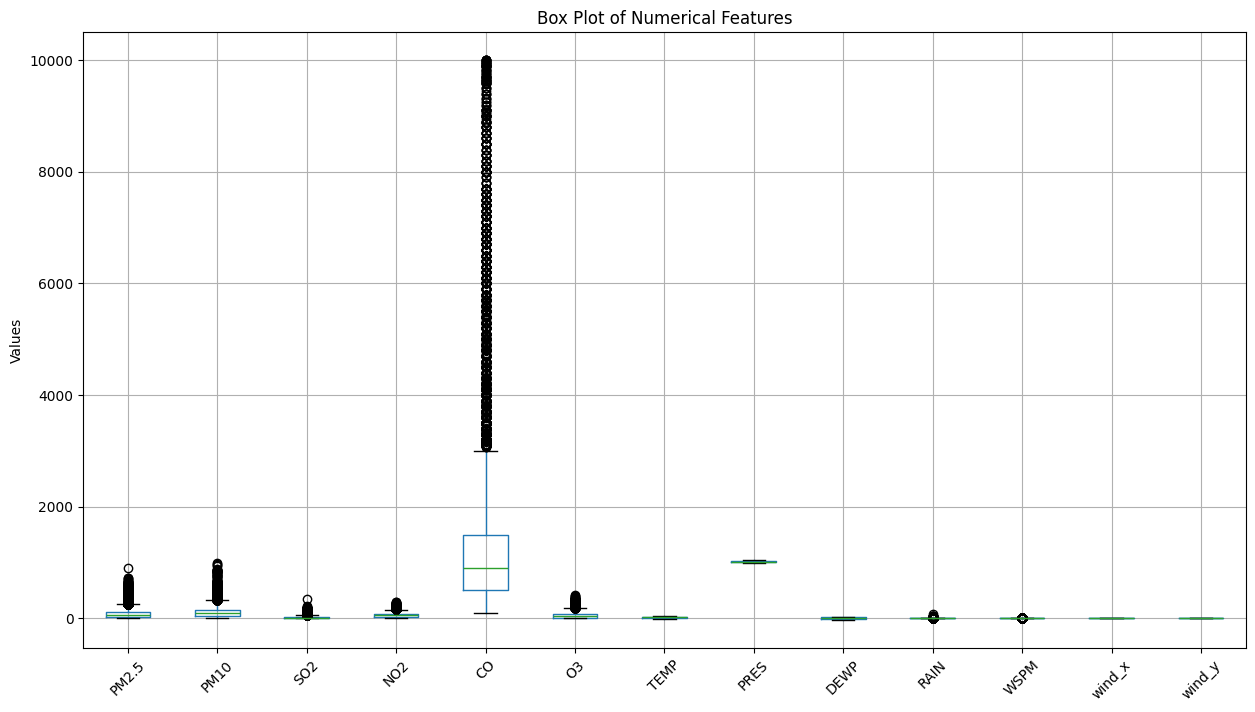

In [87]:
# Create a box plot for all numerical columns in the DataFrame
df.boxplot(figsize=(15, 8), rot=45)
plt.title("Box Plot of Numerical Features")
plt.ylabel("Values")
plt.show()

In [88]:
# Calcular el número de outliers para cada columna numérica
outliers_percentage = {}
for column in df.select_dtypes(include=[np.number]).columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_percentage[column] = f'{round(((df[column] < lower_bound) | (df[column] > upper_bound)).sum()/len(df) * 100, 4)} %'

# Mostrar el número de outliers por columna
outliers_percentage

{'PM2.5': '4.7142 %',
 'PM10': '3.2227 %',
 'SO2': '8.1679 %',
 'NO2': '1.5971 %',
 'CO': '7.6859 %',
 'O3': '3.9898 %',
 'TEMP': '0.0 %',
 'PRES': '0.0 %',
 'DEWP': '0.0 %',
 'RAIN': '3.9357 %',
 'WSPM': '4.9738 %',
 'wind_x': '0.0 %',
 'wind_y': '0.0 %'}

In [102]:
df['y'] = df['PM2.5']
df.drop(columns=['PM2.5'], inplace=True)

In [103]:
df.to_parquet(os.path.join(DATA_PATH, 'beijing_air_quality', 'clean.parquet'))